In [ ]:
!pip install pyarrow

# AI-Based Network Intrusion Detection System
### Using Machine Learning and Neural Networks

## 1. Problem Understanding

Cybersecurity threats are rapidly increasing in modern digital systems.
Manual monitoring of network traffic is inefficient and error-prone.

This project aims to develop a supervised machine learning system that automatically classifies network traffic as:

- Benign (Normal Activity)
- Malicious (Attack Activity)

This system functions as an Intrusion Detection System (IDS).

---

## 2. Objective

- Analyze network traffic dataset (UNSW-NB15)
- Perform detailed data preprocessing
- Train multiple ML models
- Implement a Neural Network
- Compare performance using evaluation metrics
- Identify the most effective model for intrusion detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")
!pip install pyarrow

In [ ]:
df_train = pd.read_parquet("UNSW_NB15_training-set.parquet")
df_test = pd.read_parquet("UNSW_NB15_testing-set.parquet")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (175341, 36)
Test shape: (82332, 36)


In [ ]:
# Drop attack category (VERY IMPORTANT)
df_train = df_train.drop(columns=['attack_cat'], errors='ignore')
df_test = df_test.drop(columns=['attack_cat'], errors='ignore')

## 3. Data Study (Exploratory Data Analysis)

Before applying preprocessing, it is important to understand:

- Data types
- Missing values
- Duplicate records
- Class distribution
- Feature relationships

Preprocessing should always be justified based on data analysis.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

In [ ]:
df_train.isnull().sum()

,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0
sload,0


In [ ]:
print("Duplicate rows:", df_train.duplicated().sum())

Duplicate rows: 82984


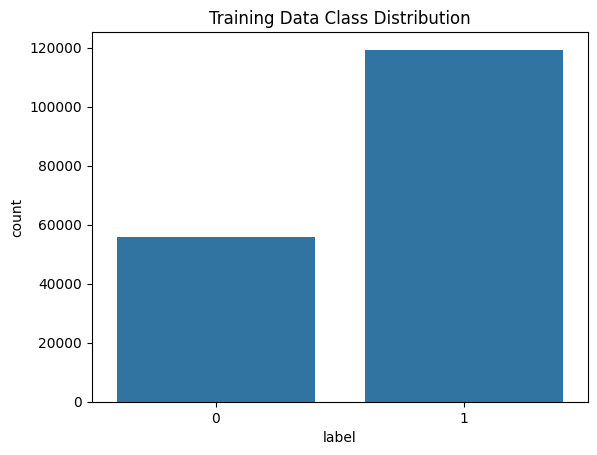

In [ ]:
sns.countplot(x=df_train['label'])
plt.title("Training Data Class Distribution")
plt.show()

If class distribution is imbalanced, models may become biased.
This justifies careful evaluation using precision, recall, and F1-score.

In [ ]:
df_train.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,...,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712055e+05,4.953000,6.948010,...,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.483313,136.887597,110.258271,1.747656e+05,1.436542e+05,165417.671875,1.883701e+08,2.423637e+06,66.005059,52.732999,...,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,...,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


## 4. Data Preprocessing

Preprocessing is necessary because:

1. ML models cannot handle categorical text features directly.
2. Features with different scales affect distance-based models and Neural Networks.
3. Duplicate records may bias the model.
4. Missing values reduce model reliability.

In [ ]:
# Step 1: Remove duplicates separately (safer)
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

X_train = df_train.drop("label", axis=1)
y_train = df_train["label"]

X_test = df_test.drop("label", axis=1)
y_test = df_test["label"]

In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


One-Hot Encoding converts categorical variables into binary vectors.
This prevents false ordinal relationships.

## Feature Correlation Analysis

A correlation heatmap is used to understand relationships between numerical features.

Highly correlated features may:
- Indicate multicollinearity
- Provide insight into important behavioral patterns
- Help in feature selection

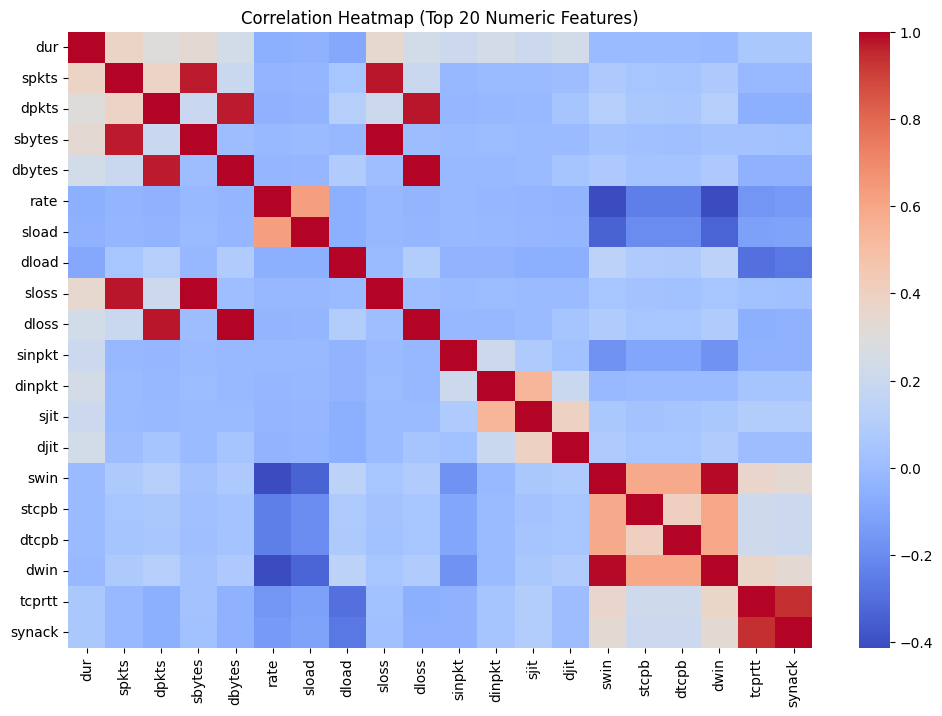

In [ ]:
# Select only numeric columns
numeric_df = df_train.select_dtypes(include=[np.number])

# Limit to first 20 numeric features (to keep heatmap readable)
numeric_df = numeric_df.iloc[:, :20]

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Top 20 Numeric Features)")
plt.show()

Highly correlated features may cause multicollinearity.
Feature importance from Random Forest will also help identify influential features.

Feature scaling ensures all features contribute equally.
It is especially important for:
- KNN
- SVM
- Neural Networks

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Model Development

We implement multiple models to compare performance:

- Logistic Regression (Linear Model)
- Linear SVM
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Neural Network (MLP)

In [ ]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

### Neural Network Architecture

- Input Layer: Number of features
- Hidden Layer 1: 128 neurons (ReLU)
- Hidden Layer 2: 64 neurons (ReLU)
- Hidden Layer 3: 32 neurons (ReLU)
- Output Layer: 1 neuron (Sigmoid)

This architecture allows learning nonlinear feature interactions.

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=400,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

## 6. Evaluation Metrics

- Accuracy = (TP + TN) / Total
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 Score = Harmonic mean of Precision and Recall
- False Positive Rate = FP / (FP + TN)
- ROC Curve = Tradeoff between TPR and FPR

In [ ]:
def evaluate(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr = cm[0][1] / (cm[0][1] + cm[0][0])
    return acc, prec, rec, f1, fpr

models = {
    "LogisticRegression": y_pred_lr,
    "DecisionTree": y_pred_dt,
    "RandomForest": y_pred_rf,
    "KNN": y_pred_knn,
    "NeuralNetwork": y_pred_mlp
}

results = []

for name, preds in models.items():
    acc, prec, rec, f1, fpr = evaluate(y_test, preds)
    results.append([name, acc, prec, rec, f1, fpr])

results_df = pd.DataFrame(results, columns=[
    "model", "accuracy", "precision", "recall", "f1", "fpr"
])

results_df.set_index("model")

,accuracy,precision,recall,f1,fpr
model,,,,,
LogisticRegression,0.716481,0.554194,0.926536,0.693551,0.394780
DecisionTree,0.820156,0.684827,0.890402,0.774200,0.217052
RandomForest,0.813124,0.662629,0.937765,0.776547,0.252895
KNN,0.760739,0.602229,0.910231,0.724869,0.318444
NeuralNetwork,0.781006,0.624605,0.921221,0.744455,0.293262


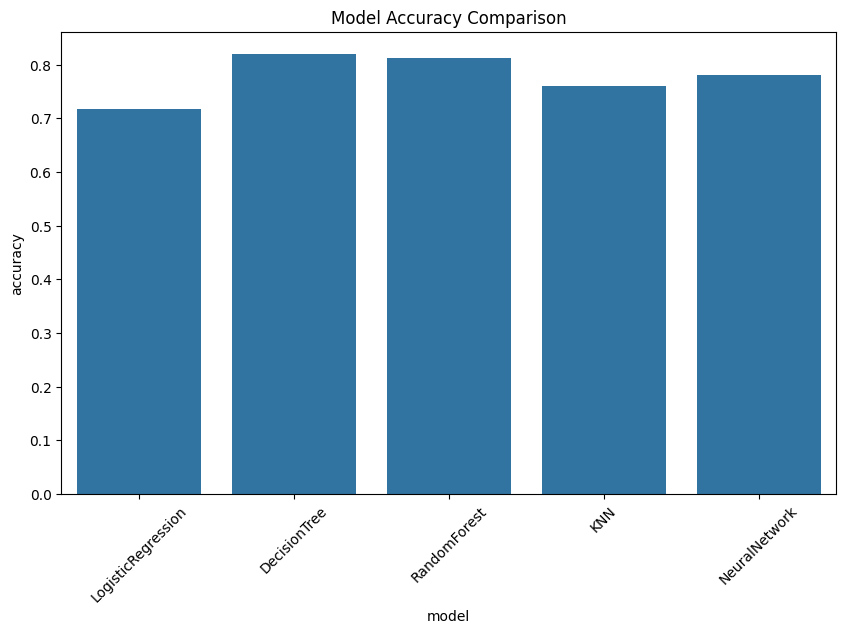

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=results_df["model"], y=results_df["accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

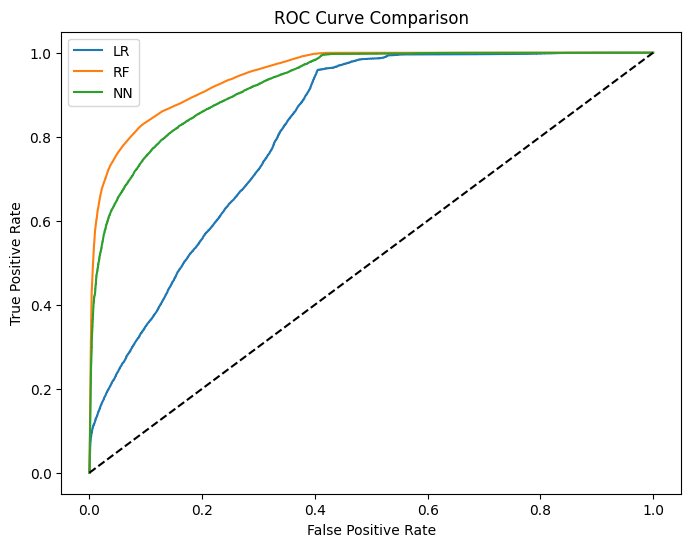

In [ ]:
plt.figure(figsize=(8,6))

for model_name, model in zip(
    ["LR","RF","NN"],
    [lr, rf, mlp]
):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 7. Conclusion

- Random Forest and Neural Network achieved highest performance.
- Neural Network effectively captured nonlinear patterns.
- Recall is critical in cybersecurity to avoid missing attacks.
- The system demonstrates how AI can enhance intrusion detection.

Future Improvements:
- Hyperparameter tuning
- Deep learning frameworks (TensorFlow)
- Real-time deployment